Exploratory Data Anlysis of Global YouTube Statistics

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load your cleaned dataset
file_path = r"F:\Data Analytics Real time Project portfolio\Global Youtube Statistics\Cleaned_Dataset_Global_YouTube_Statistics.xlsx"
df_eda = pd.read_excel(file_path)

# Quick check
print("Dataset Shape:", df_eda.shape)
# Force pandas to remove all row and column display limits
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Display the entire cleaned dataset
df_eda

Dataset Shape: (995, 7)


,Youtuber,subscribers,video views,category,Country,highest_monthly_earnings,subscribers_for_last_30_days
0,T-Series,245000000,228000000000,Music,India,9000000.00,2000000
1,YouTube Movies,170000000,0,Film Animation,United States,0.05,0
2,MrBeast,166000000,28368841870,Entertainment,United States,5400000.00,8000000
3,Cocomelon - Nursery Rhymes,162000000,164000000000,Education,United States,7900000.00,1000000
4,SET India,159000000,148000000000,Shows,India,7300000.00,1000000
5,Music,119000000,0,Unknown,Unknown,0.00,0
6,Kids Diana Show,112000000,93247040539,People Blogs,United States,2900000.00,0
7,PewDiePie,111000000,29058044447,Gaming,Japan,156700.00,0
8,Like Nastya,106000000,90479060027,People Blogs,Russia,195800.00,100000
9,Vlad and Niki,98900000,77180169894,Entertainment,United States,2300000.00,600000


C:\Users\inder\AppData\Local\Temp\ipykernel_4560\1777081894.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='subscribers', y='Youtuber', data=top_10_creators, palette='Reds_r')
C:\Users\inder\AppData\Local\Temp\ipykernel_4560\1777081894.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


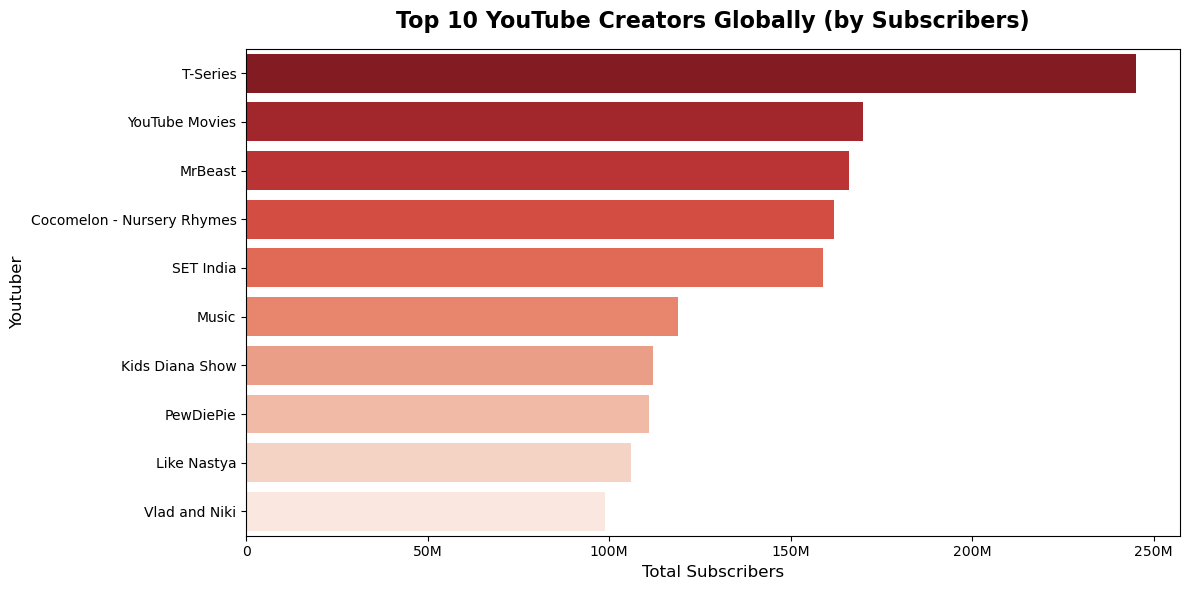

In [6]:
# Exploratory Data Analysis of Top Creators By Subscriber & Views 

# Sorting data for top 10 creators by subscribers
top_10_creators = df_eda.sort_values(by='subscribers', ascending=False).head(10)

plt.figure(figsize=(12, 6))
# Creating a barplot for Subscribers
ax = sns.barplot(x='subscribers', y='Youtuber', data=top_10_creators, palette='Reds_r')

# Formatting X-axis numbers to 'M' (Millions)
labels = [f'{x*1e-6:.0f}M' if x != 0 else '0' for x in ax.get_xticks()]
ax.set_xticklabels(labels)

plt.title('Top 10 YouTube Creators Globally (by Subscribers)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Subscribers', fontsize=12)
plt.ylabel('Youtuber', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\inder\AppData\Local\Temp\ipykernel_4560\4036988858.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{x*1e-6:.1f}M' if x >= 1e6 else f'{x*1e-3:.0f}K' for x in ax.get_xticks()])


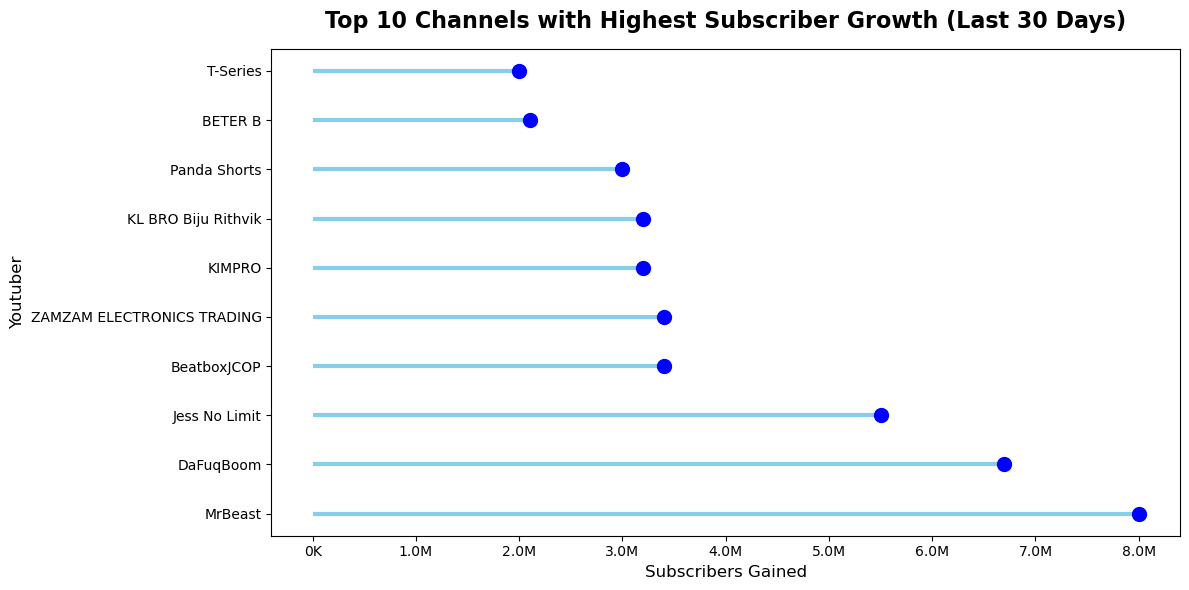

In [7]:
# Exploratory Data Analysis Subscriber Growth (Last 30 Days)

# Sorting data for top 10 fastest growing creators in the last 30 days
top_growth = df_eda.sort_values(by='subscribers_for_last_30_days', ascending=False).head(10)

plt.figure(figsize=(12, 6))
# Creating the lines and dots for the lollipop chart
plt.hlines(y=top_growth['Youtuber'], xmin=0, xmax=top_growth['subscribers_for_last_30_days'], color='skyblue', linewidth=3)
plt.plot(top_growth['subscribers_for_last_30_days'], top_growth['Youtuber'], "o", markersize=10, color='blue')

# Formatting X-axis
ax = plt.gca()
ax.set_xticklabels([f'{x*1e-6:.1f}M' if x >= 1e6 else f'{x*1e-3:.0f}K' for x in ax.get_xticks()])

plt.title('Top 10 Channels with Highest Subscriber Growth (Last 30 Days)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Subscribers Gained', fontsize=12)
plt.ylabel('Youtuber', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\inder\AppData\Local\Temp\ipykernel_4560\870398760.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=country_counts.values, y=country_counts.index, palette='magma')


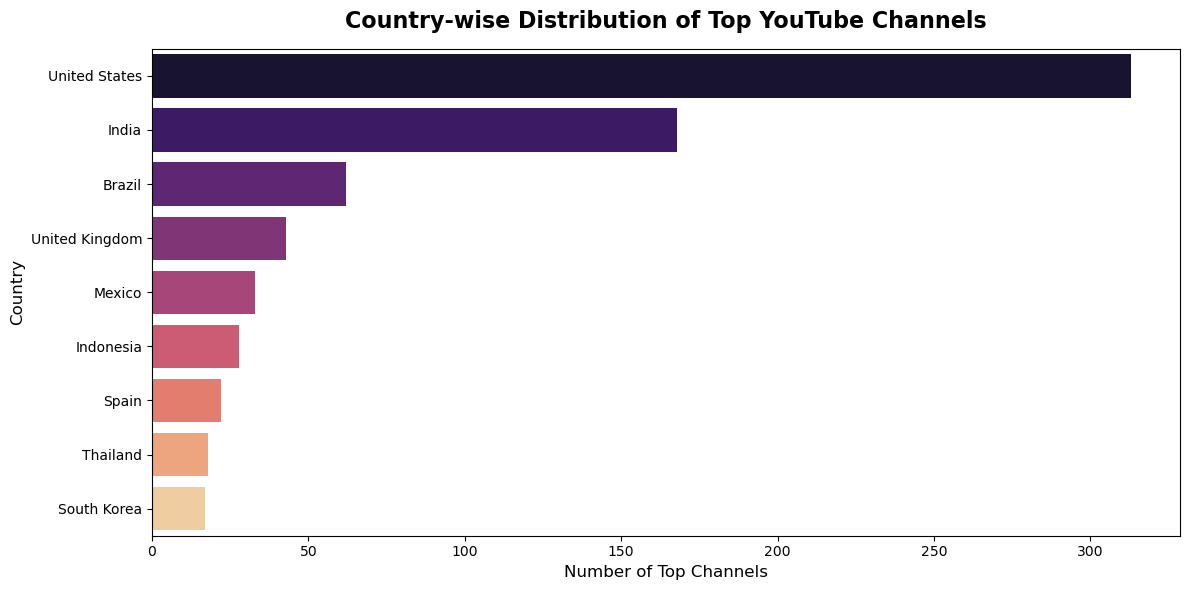

In [10]:
# Exploratory Data Analysis Country Trends (Where are the top creators from?)

# Counting how many top creators belong to each country (Top 10 Countries)
country_counts = df_eda['Country'].value_counts().head(10)

# We exclude 'Unknown' from the main focus if it appears high, to keep data clean
if 'Unknown' in country_counts.index:
    country_counts = country_counts.drop('Unknown')

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=country_counts.values, y=country_counts.index, palette='magma')

plt.title('Country-wise Distribution of Top YouTube Channels', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Top Channels', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\inder\AppData\Local\Temp\ipykernel_4488\4112389128.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=category_views.values, y=category_views.index, palette='viridis')
C:\Users\inder\AppData\Local\Temp\ipykernel_4488\4112389128.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


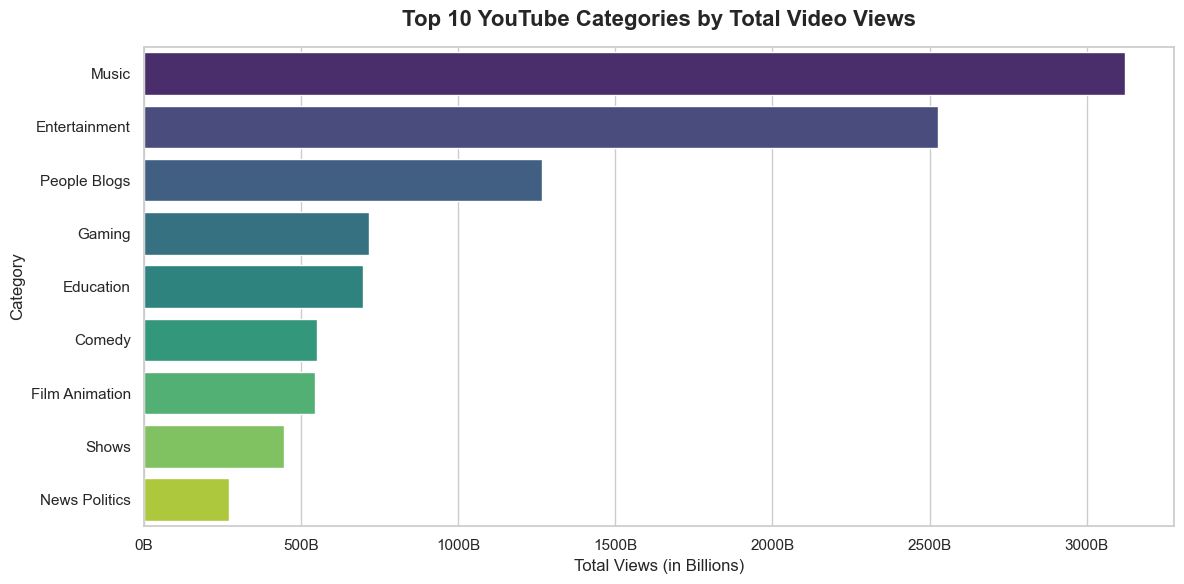

In [11]:
# Exploratory Data Analysis Categories (Which content genre rules YouTube?)

# Grouping by category and summing up the total views, then taking top 10
category_views = df_eda.groupby('category')['video views'].sum().sort_values(ascending=False).head(10)

if 'Unknown' in category_views.index:
    category_views = category_views.drop('Unknown')

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=category_views.values, y=category_views.index, palette='viridis')

# Formatting X-axis numbers to 'B' (Billions)
labels = [f'{x*1e-9:.0f}B' for x in ax.get_xticks()]
ax.set_xticklabels(labels)

plt.title('Top 10 YouTube Categories by Total Video Views', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Views (in Billions)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\inder\AppData\Local\Temp\ipykernel_4488\3812882453.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{x*1e-9:.0f}B' for x in ax.get_xticks()])
C:\Users\inder\AppData\Local\Temp\ipykernel_4488\3812882453.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{y*1e-6:.1f}M' for y in ax.get_yticks()])


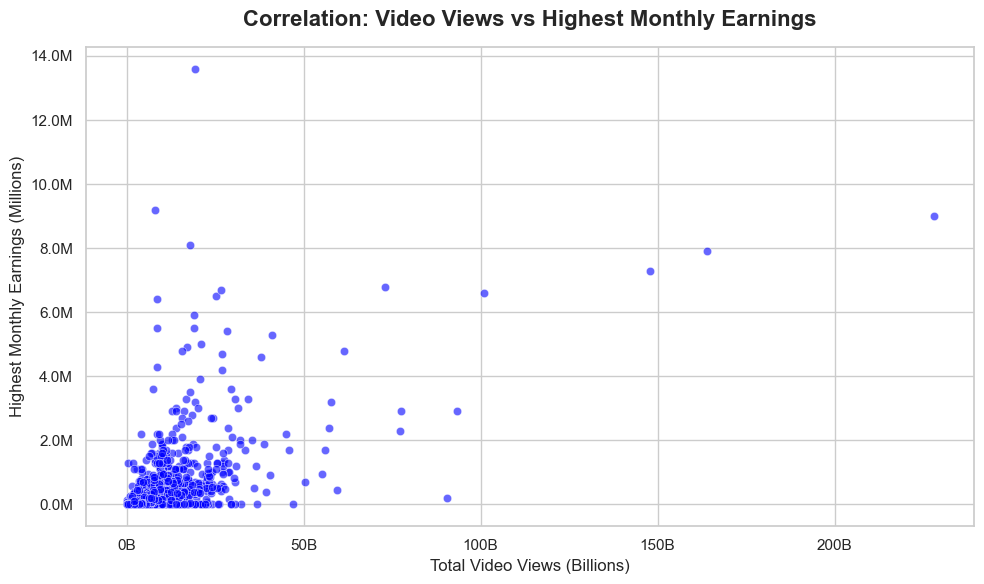

In [12]:
# Exploratory Data Analysis Views vs Earnings (Correlation Analysis)

plt.figure(figsize=(10, 6))

# Using scatterplot to see the relation between Views and Earnings
sns.scatterplot(
    data=df_eda, 
    x='video views', 
    y='highest_monthly_earnings', 
    alpha=0.6, 
    color='blue'
)

# Customizing axes labels to Billions and Millions
plt.title('Correlation: Video Views vs Highest Monthly Earnings', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Video Views (Billions)', fontsize=12)
plt.ylabel('Highest Monthly Earnings (Millions)', fontsize=12)

# Formatting axes
ax = plt.gca()
ax.set_xticklabels([f'{x*1e-9:.0f}B' for x in ax.get_xticks()])
ax.set_yticklabels([f'{y*1e-6:.1f}M' for y in ax.get_yticks()])

plt.tight_layout()
plt.show()